##  Eigenvalue Computation in Python

This notebook implements the classical power method for computing the
dominant eigenvalue of a matrix.

## Objectives

- implement the power method
- analyze convergence behaviour
- compare computed eigenvalues with reference solutions
- study residual decay during the iteration

Convergence experiment
Matrix dimension n                  : 30
Dominant eigenvalue (reference)     : 7.209343e+00
Dominant eigenvalue (power method)  : 7.209343e+00
Rayleigh quotient of final vector   : 7.209343e+00
Final residual norm                 : 2.138957e-04



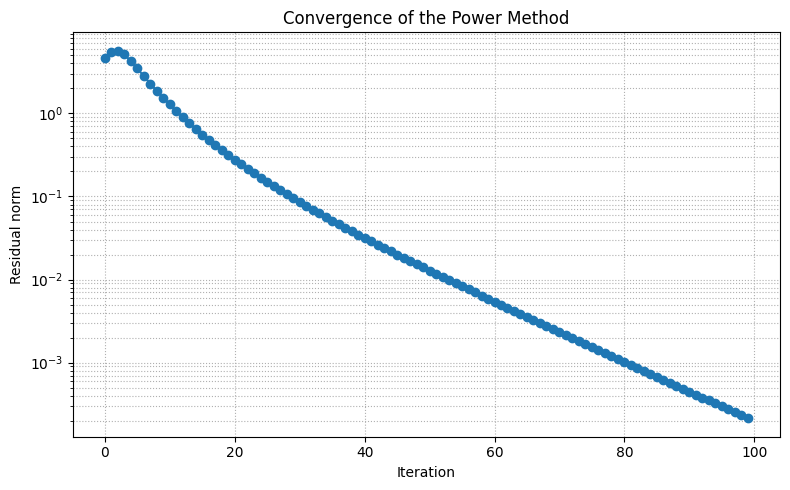

Conclusion
The power method converges to the dominant eigenvalue
when one eigenvalue dominates in magnitude and the initial vector
has a component in the direction of the corresponding eigenvector.
Plot saved to: power_method_convergence.png


In [1]:
# ================================================
# Eigenvalue Computation in Python
# Power Method and Convergence Analysis
# ================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Power method
# ------------------------------------------------
def power_method(A, x0=None, tol=1e-10, max_iter=100):
    """
    Compute the dominant eigenvalue of a matrix using the power method.

    Parameters
    ----------
    A : np.ndarray
        Square matrix.
    x0 : np.ndarray, optional
        Initial vector.
    tol : float
        Convergence tolerance.
    max_iter : int
        Maximum number of iterations.

    Returns
    -------
    eigenvalue : float
        Approximation of the dominant eigenvalue.
    eigenvector : np.ndarray
        Approximation of the dominant eigenvector.
    residuals : np.ndarray
        Residual norms over iterations.
    """
    A = np.asarray(A, dtype=float)

    n = A.shape[0]
    if A.ndim != 2 or A.shape[1] != n:
        raise ValueError("Matrix must be square.")

    if x0 is None:
        rng = np.random.default_rng(42)
        x = rng.random(n)
    else:
        x = np.asarray(x0, dtype=float)
        if x.shape[0] != n:
            raise ValueError("Dimensions of A and x0 do not match.")

    norm_x = np.linalg.norm(x)
    if norm_x < 1e-15:
        raise ValueError("Initial vector must be nonzero.")
    x = x / norm_x

    residuals = []
    eigenvalue = 0.0

    for _ in range(max_iter):
        y = A @ x
        norm_y = np.linalg.norm(y)

        if norm_y < 1e-15:
            raise ZeroDivisionError("Encountered zero vector during iteration.")

        eigenvalue_new = np.dot(x, y)
        x = y / norm_y

        residual = np.linalg.norm(A @ x - eigenvalue_new * x)
        residuals.append(residual)

        if abs(eigenvalue_new - eigenvalue) < tol:
            eigenvalue = eigenvalue_new
            break

        eigenvalue = eigenvalue_new

    return eigenvalue, x, np.array(residuals)


# ------------------------------------------------
# Rayleigh quotient
# ------------------------------------------------
def rayleigh_quotient(A, x):
    """
    Compute the Rayleigh quotient.
    """
    A = np.asarray(A, dtype=float)
    x = np.asarray(x, dtype=float)

    denominator = x @ x
    if abs(denominator) < 1e-15:
        raise ZeroDivisionError("Rayleigh quotient is undefined for the zero vector.")

    return (x @ (A @ x)) / denominator


# ------------------------------------------------
# Test matrix generator
# ------------------------------------------------
def generate_test_matrix(n, seed=0):
    """
    Generate a symmetric test matrix.
    """
    if n < 2:
        raise ValueError("n must be at least 2.")

    rng = np.random.default_rng(seed)
    M = rng.normal(size=(n, n))
    A = (M + M.T) / 2

    return A


# ------------------------------------------------
# Convergence experiment
# ------------------------------------------------
def convergence_experiment(n=30, seed=0, tol=1e-10, max_iter=100):
    """
    Run a convergence experiment for the power method.
    """
    A = generate_test_matrix(n, seed=seed)

    true_eigvals = np.linalg.eigvalsh(A)
    idx = np.argmax(np.abs(true_eigvals))
    true_lambda = true_eigvals[idx]

    lambda_est, vec_est, residuals = power_method(A, tol=tol, max_iter=max_iter)
    rq = rayleigh_quotient(A, vec_est)

    print("Convergence experiment")
    print(f"Matrix dimension n                  : {n}")
    print(f"Dominant eigenvalue (reference)     : {true_lambda:.6e}")
    print(f"Dominant eigenvalue (power method)  : {lambda_est:.6e}")
    print(f"Rayleigh quotient of final vector   : {rq:.6e}")
    print(f"Final residual norm                 : {residuals[-1]:.6e}")
    print()

    plt.figure(figsize=(8, 5))
    plt.semilogy(np.arange(len(residuals)), residuals, "o-")
    plt.xlabel("Iteration")
    plt.ylabel("Residual norm")
    plt.title("Convergence of the Power Method")
    plt.grid(True, which="both", linestyle=":")
    plt.tight_layout()
    plt.show()

    return {
        "A": A,
        "true_lambda": true_lambda,
        "lambda_est": lambda_est,
        "rayleigh_quotient": rq,
        "residuals": residuals,
        "eigenvector": vec_est,
    }


# ------------------------------------------------
# Save convergence plot
# ------------------------------------------------
def save_convergence_plot(results, filename="power_method_convergence.png"):
    """
    Save the convergence plot of the power method to an image file.
    """
    residuals = results["residuals"]

    plt.figure(figsize=(8, 5))
    plt.semilogy(np.arange(len(residuals)), residuals, "o-")
    plt.xlabel("Iteration")
    plt.ylabel("Residual norm")
    plt.title("Convergence of the Power Method")
    plt.grid(True, which="both", linestyle=":")
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Plot saved to: {filename}")


# ------------------------------------------------
# Example execution
# ------------------------------------------------
results = convergence_experiment(n=30, seed=0, tol=1e-10, max_iter=100)

print("Conclusion")
print("The power method converges to the dominant eigenvalue")
print("when one eigenvalue dominates in magnitude and the initial vector")
print("has a component in the direction of the corresponding eigenvector.")

# Save PNG for later download
save_convergence_plot(results, filename="power_method_convergence.png")

## Conclusion

The experiments demonstrate that the power method is a simple but effective
algorithm for approximating the dominant eigenvalue of a matrix. The method
iteratively amplifies the component of the initial vector in the direction
of the dominant eigenvector.

The convergence rate depends on the ratio between the largest and the
second-largest eigenvalue in magnitude. If the dominant eigenvalue is well
separated, the method converges rapidly. Otherwise, convergence may be slow.

Although the power method is computationally simple, it forms the basis for
many modern numerical algorithms in scientific computing, including methods
used in large-scale eigenvalue problems and data analysis applications.